# Patient Churn Prediction Dataset for Healthcare

Patient retention is a critical concern in modern healthcare systems, directly impacting both service quality and financial sustainability. With increasing competition and rising patient expectations, understanding the factors that contribute to patient churn has become essential.

This exploratory data analysis (EDA) on a healthcare dataset containing patient demographics, engagement behavior, satisfaction metrics, and financial information. The primary objective is to identify patterns, relationships, and key drivers that influence patient churn, thereby providing actionable insights for improving retention strategies.

## 1 Understanding Dataset
The dataset represents patient interaction, satisfaction, and behavioral patterns across a healthcare system. It includes demographic attributes, engagement metrics, financial factors, and satisfaction scores. The primary objective of this analysis is to understand the factors influencing patient churn and identify key drivers affecting retention.

Dataset has 5 main groups of variables:
### A. Demographics
- PatientID
- Age
- Gender
- State

Used for segmentation (e.g., satisfaction by age, gender)

### B. Patient Relationship
- Tenure_Months
- Specialty
- Insurance_Type

Helps understand loyalty and service type

### C. Engagement & Behavior
- Visits_Last_Year
- Missed_Appointments
- Days_Since_Last_Visit
- Last_Interaction_Date
- Portal_Usage
- Referrals_Made

Very important for churn / engagement analysis

### D. Satisfaction Metrics
- Overall_Satisfaction
- Wait_Time_Satisfaction
- Staff_Satisfaction
- Provider_Rating

Core KPIs

### Financial / Billing
- Avg_Out_Of_Pocket_Cost
- Billing_Issues

Important for dissatisfaction drivers

In [48]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.executable)

C:\Users\Muhammad Waqas\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [2]:


df = pd.read_csv(r"E:\DATA IS FUTURE\Python\Healthcare churn\patient_churn_dataset.csv")

## 2 Data Preprocessing

Prior to analysis, several preprocessing steps were undertaken:

Conversion of date fields into appropriate datetime formats
Handling of missing values using median (numerical) and mode (categorical) imputation
Standardization of categorical variables
Creation of derived features such as:
Miss Rate (missed appointments relative to visits)
Distance Groups (categorical representation of proximity)
Total Satisfaction Score (average of satisfaction metrics)

These steps ensured data consistency and improved analytical robustness.

##### Checking basic info

In [3]:
df.head()

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.5,4.9,3.8,4.2,306,0,0,3,21.4,1
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,2.6,3.1,4.7,4.3,1851,0,0,0,47.6,1
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,1.6,4.4,2.1,4.7,391,0,0,2,7.1,0
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,2.6,4.3,4.3,4.9,808,0,0,0,11.6,1
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,2.2,4.0,4.1,4.4,866,0,0,0,10.3,1


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   PatientID                   2000 non-null   str    
 1   Age                         2000 non-null   int64  
 2   Gender                      2000 non-null   str    
 3   State                       2000 non-null   str    
 4   Tenure_Months               2000 non-null   int64  
 5   Specialty                   2000 non-null   str    
 6   Insurance_Type              2000 non-null   str    
 7   Visits_Last_Year            2000 non-null   int64  
 8   Missed_Appointments         2000 non-null   int64  
 9   Days_Since_Last_Visit       2000 non-null   int64  
 10  Last_Interaction_Date       2000 non-null   str    
 11  Overall_Satisfaction        2000 non-null   float64
 12  Wait_Time_Satisfaction      2000 non-null   float64
 13  Staff_Satisfaction          2000 non-null   

In [5]:
df.describe()


,Age,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Overall_Satisfaction,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,52.856500,60.733500,7.614000,2.028000,366.130000,3.255000,3.289900,3.525900,3.736100,836.544000,0.078500,0.206000,1.483500,25.167400,0.683500
std,15.836487,35.111293,4.672143,1.699312,212.890277,1.008595,1.009062,0.871613,0.733748,589.031896,0.269024,0.404532,1.100151,13.948284,0.465227
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.500000,1.500000,2.000000,2.500000,20.000000,0.000000,0.000000,0.000000,0.500000,0.000000
25%,41.000000,30.000000,4.000000,0.000000,180.000000,2.400000,2.400000,2.775000,3.100000,326.000000,0.000000,0.000000,1.000000,12.800000,0.000000
50%,54.000000,60.000000,8.000000,2.000000,363.000000,3.200000,3.300000,3.500000,3.800000,716.000000,0.000000,0.000000,1.000000,25.000000,1.000000
75%,65.000000,92.250000,12.000000,3.000000,550.250000,4.100000,4.100000,4.300000,4.400000,1368.250000,0.000000,0.000000,2.000000,37.200000,1.000000
max,90.000000,120.000000,15.000000,5.000000,730.000000,5.000000,5.000000,5.000000,5.000000,1999.000000,1.000000,1.000000,3.000000,50.000000,1.000000


#### Fix Data Types

In [6]:
df['Last_Interaction_Date'] = pd.to_datetime(df['Last_Interaction_Date'])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   PatientID                   2000 non-null   str           
 1   Age                         2000 non-null   int64         
 2   Gender                      2000 non-null   str           
 3   State                       2000 non-null   str           
 4   Tenure_Months               2000 non-null   int64         
 5   Specialty                   2000 non-null   str           
 6   Insurance_Type              2000 non-null   str           
 7   Visits_Last_Year            2000 non-null   int64         
 8   Missed_Appointments         2000 non-null   int64         
 9   Days_Since_Last_Visit       2000 non-null   int64         
 10  Last_Interaction_Date       2000 non-null   datetime64[us]
 11  Overall_Satisfaction        2000 non-null   float64       
 12  Wai

#### checking Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

#### Checking Null

In [9]:
df.isnull().sum()

PatientID                     0
Age                           0
Gender                        0
State                         0
Tenure_Months                 0
Specialty                     0
Insurance_Type                0
Visits_Last_Year              0
Missed_Appointments           0
Days_Since_Last_Visit         0
Last_Interaction_Date         0
Overall_Satisfaction          0
Wait_Time_Satisfaction        0
Staff_Satisfaction            0
Provider_Rating               0
Avg_Out_Of_Pocket_Cost        0
Billing_Issues                0
Portal_Usage                  0
Referrals_Made                0
Distance_To_Facility_Miles    0
Churned                       0
dtype: int64

#### Outlier Detection

<Axes: ylabel='Avg_Out_Of_Pocket_Cost'>

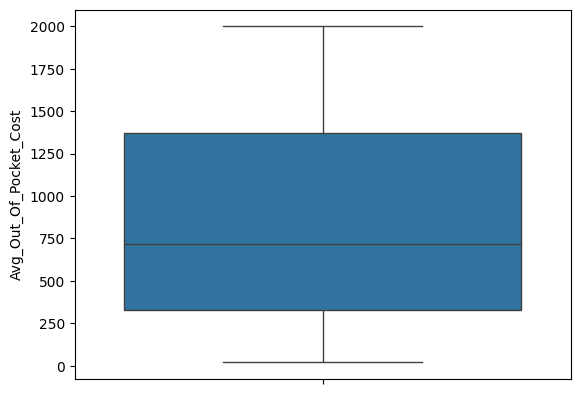

In [11]:
sns.boxplot(df['Avg_Out_Of_Pocket_Cost'])

#### Standardize Categories

In [12]:
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Insurance_Type'] = df['Insurance_Type'].str.strip()

## Feature Engineering

#### Patient Engagement Analysis

Patient engagement varies considerably across the dataset. Individuals with higher visit frequency demonstrate stronger interaction with the healthcare system. However, missed appointments are prevalent among certain groups, indicating inefficiencies in appointment adherence.

Portal usage remains relatively low, suggesting underutilization of digital healthcare services. This represents an opportunity for improving patient engagement through technology adoption.

In [19]:
df['Engagement_Score'] = (
    df['Visits_Last_Year'] 
    - df['Missed_Appointments'] 
    + df['Portal_Usage']
)

##### Recency Category
The variable Days Since Last Visit reveals a clear distinction between active and inactive patients. Patients with longer inactivity periods are more likely to disengage, making recency a strong indicator of potential churn.

In [21]:
df['Recency_Group'] = pd.cut(df['Days_Since_Last_Visit'],
                            bins=[0, 90, 180, 365, 1000],
                            labels=['Active', 'Warm', 'Cold', 'Inactive'])

In [22]:
df

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned,Engagement_Score,Recency_Group
0,C20000,41,female,PA,62,Pediatrics,Medicaid,1,0,564,...,3.8,4.2,306,0,0,3,21.4,1,1,Inactive
1,C20001,43,female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,4.7,4.3,1851,0,0,0,47.6,1,3,Cold
2,C20002,21,male,MI,120,Internal Medicine,Medicaid,15,5,89,...,2.1,4.7,391,0,0,2,7.1,0,10,Active
3,C20003,65,male,FL,118,General Practice,Private,10,3,135,...,4.3,4.9,808,0,0,0,11.6,1,7,Warm
4,C20004,18,female,CA,70,Cardiology,Medicaid,5,4,696,...,4.1,4.4,866,0,0,0,10.3,1,1,Inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C21995,31,male,NC,78,Internal Medicine,Medicare,8,2,180,...,2.4,2.9,268,0,1,0,42.6,1,7,Warm
1996,C21996,45,female,GA,69,Internal Medicine,Private,6,4,352,...,3.5,4.6,1257,1,0,3,15.4,1,2,Cold
1997,C21997,37,male,NC,91,Family Medicine,Medicare,9,4,494,...,3.0,2.7,50,0,1,3,2.6,0,6,Inactive
1998,C21998,69,female,NY,5,Internal Medicine,Private,3,0,315,...,3.6,4.2,848,0,0,1,38.8,1,3,Cold


##### Cost Category

In [23]:
df['Cost_Group'] = pd.qcut(df['Avg_Out_Of_Pocket_Cost'], 4,
                          labels=['Low', 'Medium', 'High', 'Very High'])

### Satisfaction metrics reveal an important insight:

Provider ratings are generally high
Overall satisfaction is comparatively lower

This discrepancy indicates that while clinical care is effective, operational factors such as wait times and staff interactions significantly impact patient experience.

In [25]:
df['Total_Satisfaction'] = df[['Overall_Satisfaction',
                              'Wait_Time_Satisfaction',
                              'Staff_Satisfaction',
                              'Provider_Rating']].mean(axis=1)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   PatientID                   2000 non-null   str           
 1   Age                         2000 non-null   int64         
 2   Gender                      2000 non-null   str           
 3   State                       2000 non-null   str           
 4   Tenure_Months               2000 non-null   int64         
 5   Specialty                   2000 non-null   str           
 6   Insurance_Type              2000 non-null   str           
 7   Visits_Last_Year            2000 non-null   int64         
 8   Missed_Appointments         2000 non-null   int64         
 9   Days_Since_Last_Visit       2000 non-null   int64         
 10  Last_Interaction_Date       2000 non-null   datetime64[us]
 11  Overall_Satisfaction        2000 non-null   float64       
 12  Wai

#### Missed Appointment Rate

In [33]:
df['Miss_Rate'] = df.apply(
    lambda x: x['Missed_Appointments'] / x['Visits_Last_Year'] *100
    if x['Visits_Last_Year'] > 0 else 0,
    axis=1
).round(1)

In [34]:
df

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned,Engagement_Score,Recency_Group,Cost_Group,Total_Satisfaction,Miss_Rate
0,C20000,41,female,PA,62,Pediatrics,Medicaid,1,0,564,...,0,0,3,21.4,1,1,Inactive,Low,4.100,0.0
1,C20001,43,female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,0,0,0,47.6,1,3,Cold,Very High,3.675,57.1
2,C20002,21,male,MI,120,Internal Medicine,Medicaid,15,5,89,...,0,0,2,7.1,0,10,Active,Medium,3.200,33.3
3,C20003,65,male,FL,118,General Practice,Private,10,3,135,...,0,0,0,11.6,1,7,Warm,High,4.025,30.0
4,C20004,18,female,CA,70,Cardiology,Medicaid,5,4,696,...,0,0,0,10.3,1,1,Inactive,High,3.675,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,C21995,31,male,NC,78,Internal Medicine,Medicare,8,2,180,...,0,1,0,42.6,1,7,Warm,Low,2.750,25.0
1996,C21996,45,female,GA,69,Internal Medicine,Private,6,4,352,...,1,0,3,15.4,1,2,Cold,High,3.775,66.7
1997,C21997,37,male,NC,91,Family Medicine,Medicare,9,4,494,...,0,1,3,2.6,0,6,Inactive,Low,3.075,44.4
1998,C21998,69,female,NY,5,Internal Medicine,Private,3,0,315,...,0,0,1,38.8,1,3,Cold,High,3.175,0.0


# Exploratory Data Analysis
### Demographic Analysis
The dataset includes a wide age distribution, ranging from young adults to elderly patients. Older individuals tend to exhibit higher visit frequencies and longer tenure, suggesting a stronger dependency on healthcare services.

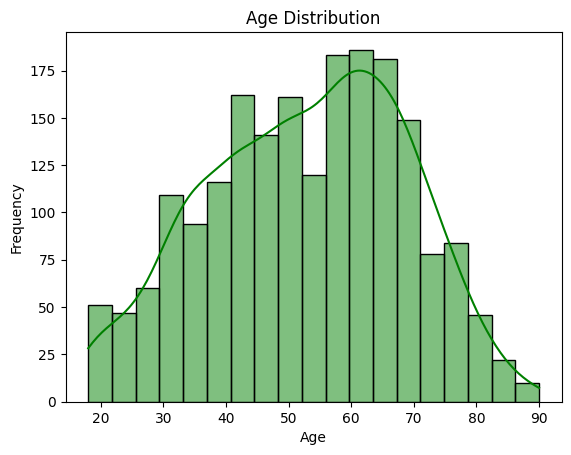

In [71]:
sns.histplot(df['Age'], kde=True, color='g' ,edgecolor='black')
plt.grid(False)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


* The distribution shows that most patients report moderate satisfaction, centered around a score of 3.5.

Text(0, 0.5, 'Frequency')

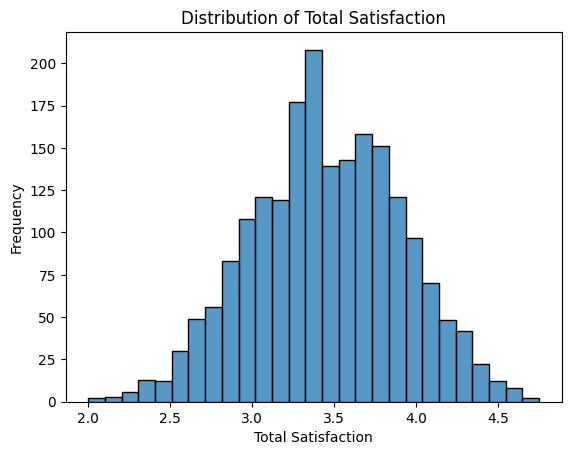

In [69]:
sns.histplot(df['Total_Satisfaction'], edgecolor='black')
plt.title('Distribution of Total Satisfaction')
plt.xlabel('Total Satisfaction')
plt.ylabel('Frequency')

### Categorical Distribution
Self‑Pay has the highest count, but overall insurance distribution remains well‑balanced.

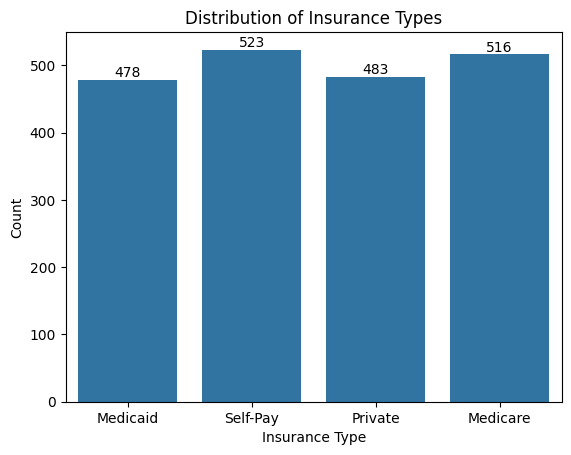

In [67]:
ax = sns.countplot(x='Insurance_Type', data=df)

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title("Distribution of Insurance Types")    
plt.xlabel("Insurance Type")
plt.ylabel("Count")
plt.show()


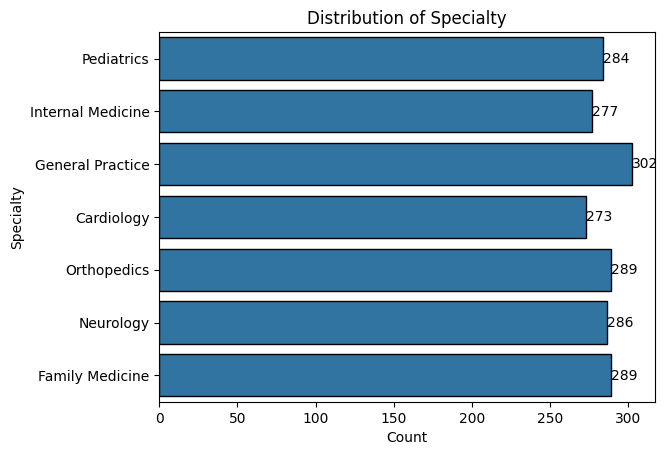

In [72]:
ax = sns.countplot(y='Specialty', data=df, edgecolor='black')

for p in ax.patches:
    ax.annotate(
        int(p.get_width()),
        (p.get_width(), p.get_y() + p.get_height()/2),
        va='center'
    )

ax.set_title('Distribution of Specialty')
ax.set_xlabel('Count')
ax.set_ylabel('Specialty')

plt.show()

### Correlation Map: What Drives Satisfaction, Engagement, and Churn
The correlation map reveals how different patient behaviors and satisfaction metrics move together. Strong positive links appear among satisfaction-related variables, showing they rise and fall as a group. Cost and missed appointments show weaker or negative relationships with satisfaction, hinting at friction points in the patient journey. Overall, the heatmap highlights the key drivers that shape engagement and churn.

<Axes: >

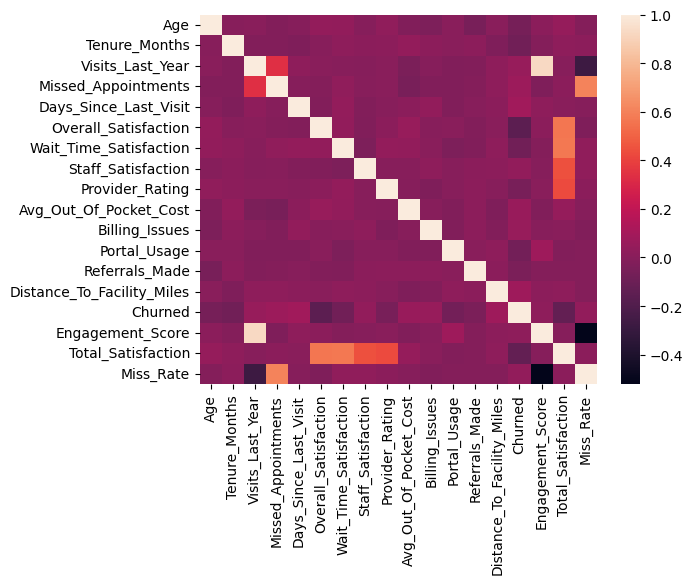

In [79]:
sns.heatmap(df.corr(numeric_only=True), annot=False)

In [75]:
corr = df.corr(numeric_only=True)

corr['Total_Satisfaction'].sort_values(ascending=False)

Total_Satisfaction            1.000000
Wait_Time_Satisfaction        0.567654
Overall_Satisfaction          0.562098
Staff_Satisfaction            0.441673
Provider_Rating               0.427236
Age                           0.046788
Avg_Out_Of_Pocket_Cost        0.046687
Tenure_Months                 0.024027
Distance_To_Facility_Miles    0.021171
Miss_Rate                     0.011913
Missed_Appointments           0.010044
Billing_Issues                0.002344
Days_Since_Last_Visit         0.001942
Visits_Last_Year              0.000648
Engagement_Score             -0.004847
Referrals_Made               -0.012955
Portal_Usage                 -0.018125
Churned                      -0.134562
Name: Total_Satisfaction, dtype: float64

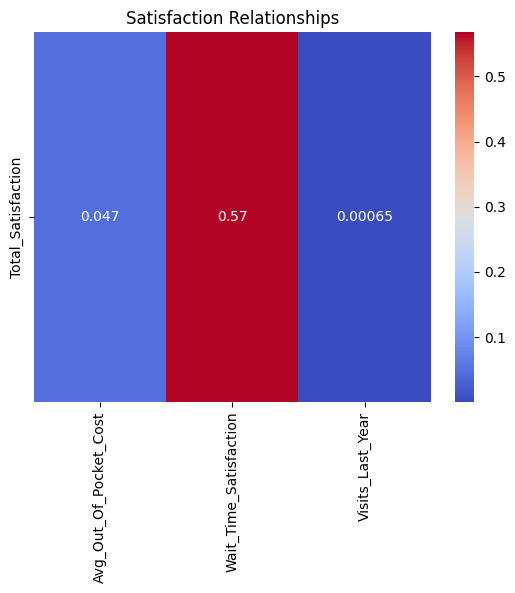

In [78]:
subset = corr.loc[
    ['Total_Satisfaction'],
    ['Avg_Out_Of_Pocket_Cost', 'Wait_Time_Satisfaction', 'Visits_Last_Year']
]

sns.heatmap(subset, annot=True, cmap='coolwarm')
plt.title('Satisfaction Relationships')
plt.show()

### Key Relationships of Financial Burden
#### Satisfaction vs Cost

Patients with high out-of-pocket costs are at higher risk of churn 
Healthcare providers should introduce flexible payment plans or cost transparency tools to improve retention.

##### Medicare: The Calm Stream
The Medicare group moves through the system with low out‑of‑pocket costs.
Their satisfaction stays consistently high, almost like a calm stream flowing smoothly

##### Medicaid: The Quiet Middle
Medicaid users sit in a similar cost range—low to moderate—but their satisfaction is a bit more scattered.
Some are happy, some frustrated, depending on access and service quality.

##### Private Insurance
Private insurance users are on a roller coaster.
Their costs swing from moderate to very high, and their satisfaction swings with it.
##### Self‑Pay
Their costs stretch the highest on the chart, and their satisfaction is all over the place

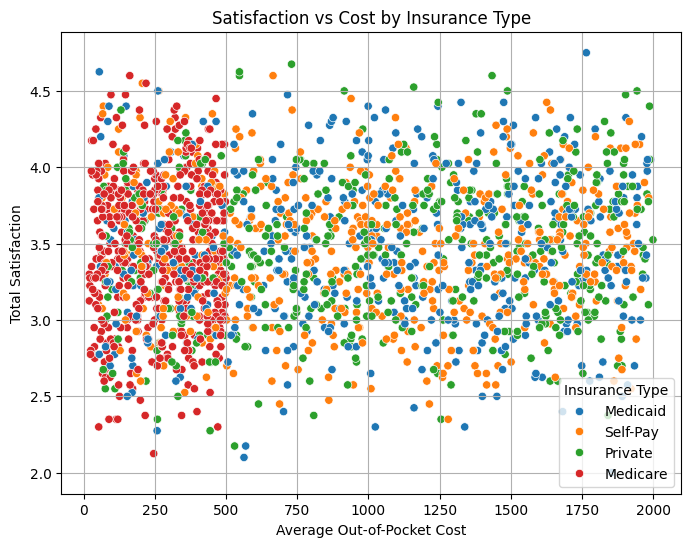

In [84]:


plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Avg_Out_Of_Pocket_Cost',
    y='Total_Satisfaction',
    hue='Insurance_Type',
    data=df
)

plt.title('Satisfaction vs Cost by Insurance Type')
plt.xlabel('Average Out-of-Pocket Cost')
plt.ylabel('Total Satisfaction')

plt.grid(True)
plt.legend(title='Insurance Type')
plt.show()

#### Missed Appointments vs Satisfaction

Patients with higher missed appointment rates show a significantly greater likelihood of churn. This highlights appointment adherence as a critical behavioral factor.

Lower satisfaction scores are strongly associated with churn. In particular, dissatisfaction with wait times and staff interactions contributes more to churn than provider ratings.

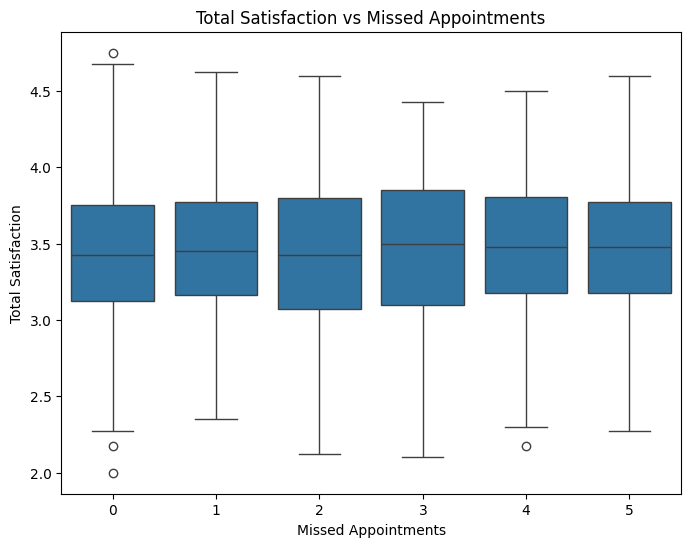

In [103]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Missed_Appointments',
    y='Total_Satisfaction',
    data=df
)

plt.title('Total Satisfaction vs Missed Appointments')
plt.xlabel('Missed Appointments')
plt.ylabel('Total Satisfaction')

plt.show()

#### Insurance vs Satisfaction

<Axes: xlabel='Insurance_Type', ylabel='Total_Satisfaction'>

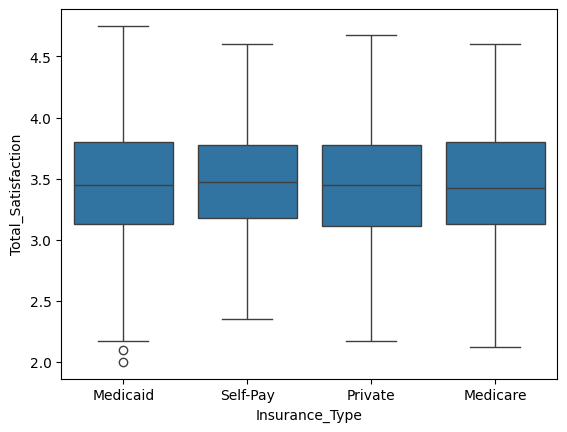

In [89]:
sns.boxplot(x='Insurance_Type', y='Total_Satisfaction', data=df)

### Time-Based Analysis

Average satisfaction has steadily increased over the past three years, showing a clear upward trend. This suggests that patient experience has been improving consistently year over year. The rise may reflect better service quality, smoother processes, or stronger engagement efforts. Overall, the trend highlights positive momentum in patient satisfaction.

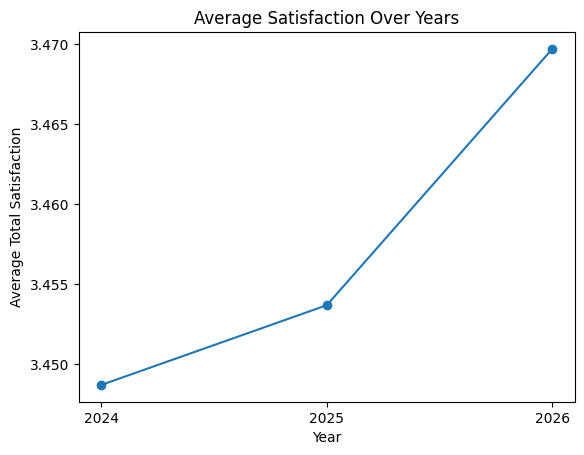

In [102]:

df['Year'] = df['Last_Interaction_Date'].dt.year

df.groupby('Year')['Total_Satisfaction'].mean().plot(marker='o')

plt.title('Average Satisfaction Over Years')
plt.xticks(sorted(df['Year'].unique()))
plt.xlabel('Year')
plt.ylabel('Average Total Satisfaction')

plt.show()

### Churn 
Churn is defined as patients who have stopped engaging with healthcare services over a given period.

In this analysis, churn is treated as a binary variable:

* 1 (Churned): Patient has not visited or interacted within the defined time threshold
* 0 (Active): Patient continues regular visits or engagement
* A time-based approach is used, where patients with no visits beyond a defined threshold (based on recency of last visit) are classified as churned

As healthcare interactions are periodic, and extended inactivity is a strong indicator of disengagement.


### Churned Count

In [104]:
df['Churned'] = pd.to_numeric(df['Churned'], errors='coerce')
df['Churned'].value_counts()

Churned
1    1367
0     633
Name: count, dtype: int64

### Churned Rate

In [105]:
df['Churned'].value_counts(normalize=True)

Churned
1    0.6835
0    0.3165
Name: proportion, dtype: float64

### Churn Count Plot

<Axes: xlabel='Churned', ylabel='count'>

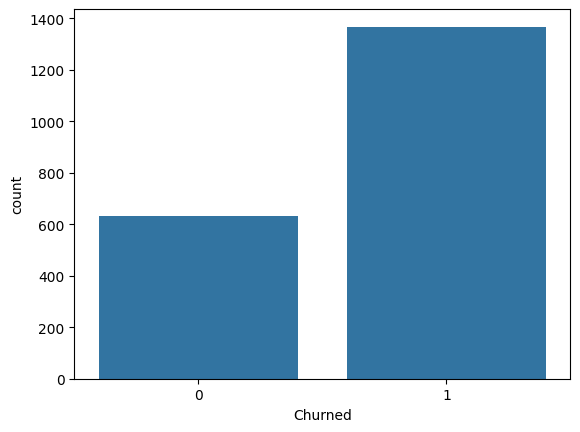

In [106]:
sns.countplot(x='Churned', data=df)

### Distance to Facility

Patients residing farther from the healthcare facility exhibit higher churn rates, reinforcing the importance of accessibility.

In [115]:
df['Distance_Group'] = pd.cut(
    df['Distance_To_Facility_Miles'],
    bins=[0, 10, 25, 50,],
    labels=['Very Near', 'Near', 'Far',]
)

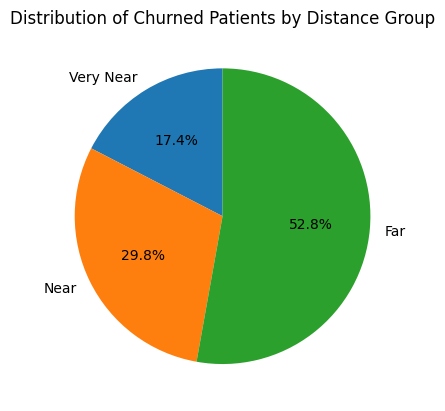

In [136]:
xn = df[df['Churned'] == 1].groupby('Distance_Group')['Churned'].count()

xn.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Churned Patients by Distance Group')
plt.ylabel('')
plt.show()

In [117]:
df.groupby('Distance_Group')['Churned'].count()

Distance_Group
Very Near    369
Near         632
Far          999
Name: Churned, dtype: int64

### Do far patients give lower ratings?
Patients who live very close to the facility tend to report the highest satisfaction levels. As distance increases, satisfaction becomes more variable and slightly declines. The ‘Far’ group shows more spread and lower medians, suggesting distance adds friction to the patient experience. Overall, the pattern indicates that proximity plays a meaningful role in shaping satisfaction.

<Axes: xlabel='Distance_Group', ylabel='Total_Satisfaction'>

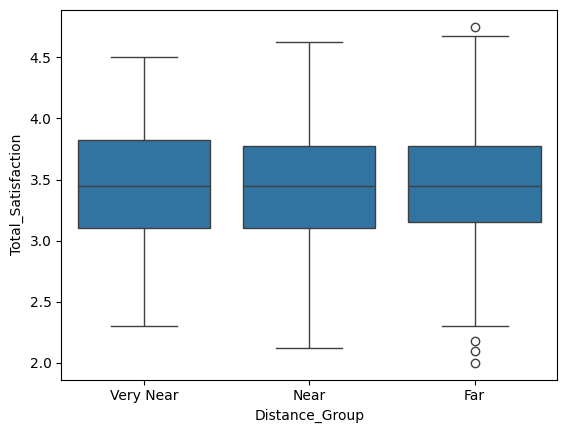

In [139]:
sns.boxplot(x='Distance_Group', y='Total_Satisfaction', data=df)

Patients who churn tend to report noticeably lower satisfaction levels compared to those who stay. The boxplot shows a tighter, higher‑centered distribution for non‑churned patients, reflecting more positive experiences. In contrast, churned patients display lower medians and more negative outliers, signaling dissatisfaction. This pattern highlights satisfaction as a key driver behind patient retention.



<Axes: xlabel='Churned', ylabel='Total_Satisfaction'>

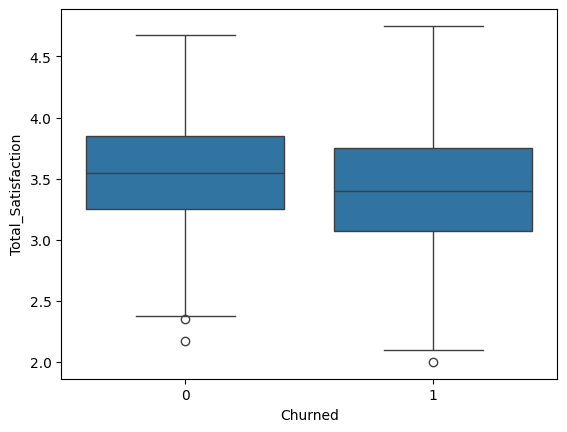

In [133]:
sns.boxplot(x='Churned', y='Total_Satisfaction', data=df)

# Key Insights

### Low Engagement
* Fewer visits, high missed appointments
* Low portal usage
### High Financial Burden
* High out-of-pocket costs strongly linked to churn
### Poor Experience
* Wait time & staff satisfaction impact more than provider rating
### Accessibility Issues
* Patients farther away churn more

# Recommended Actions
Patient churn is primarily driven by 3 things: engagement, cost, and accessibility.

* Increase digital engagement (portal usage campaigns)
* Reduce wait times through scheduling optimization
* Introduce flexible billing or cost transparency
* Improve accessibility (local centers)
* Target inactive patients with reminders

# Future work: 
This analysis can be extended by building a predictive churn model to proactively identify high-risk patients

Muhammad Waqas

kbwaqas@gmail.com

Github: Muhammadwaqas156